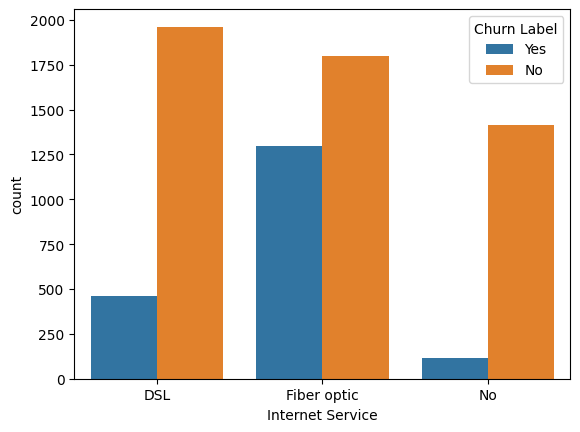

Index(['Gender', 'Senior Citizen', 'Multiple Lines', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies'],
      dtype='str')


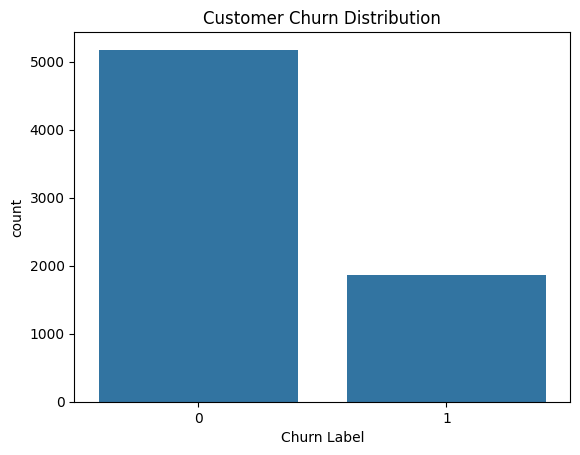

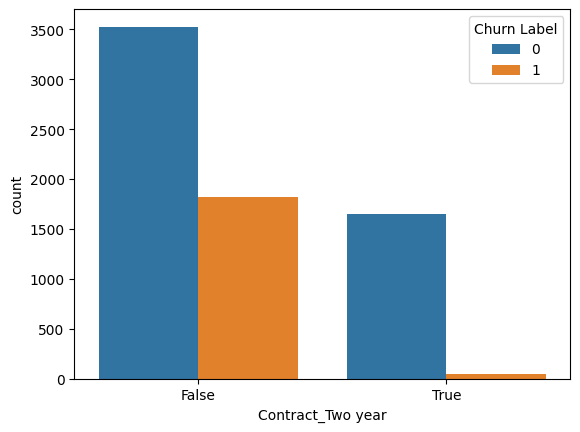

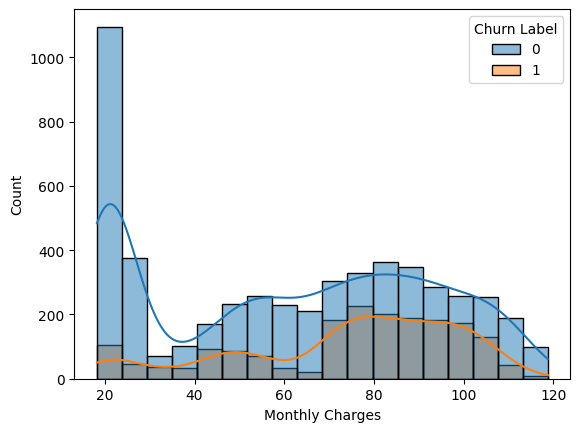

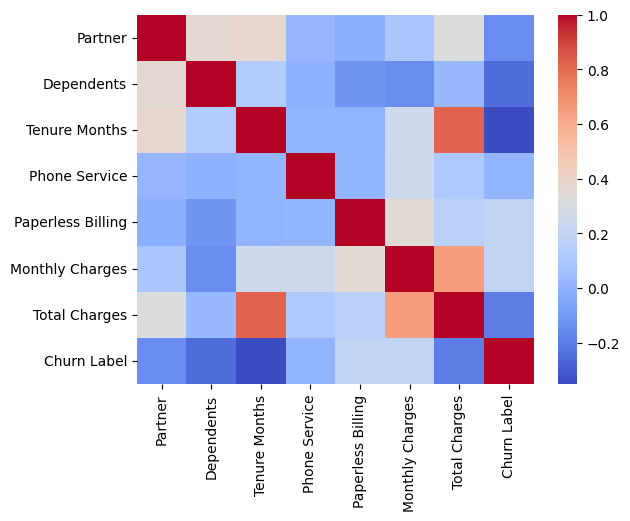

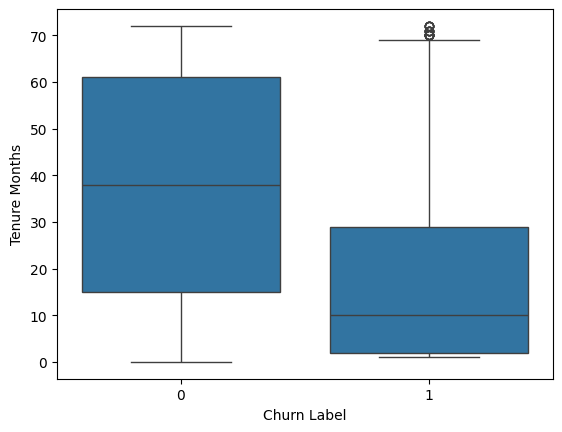

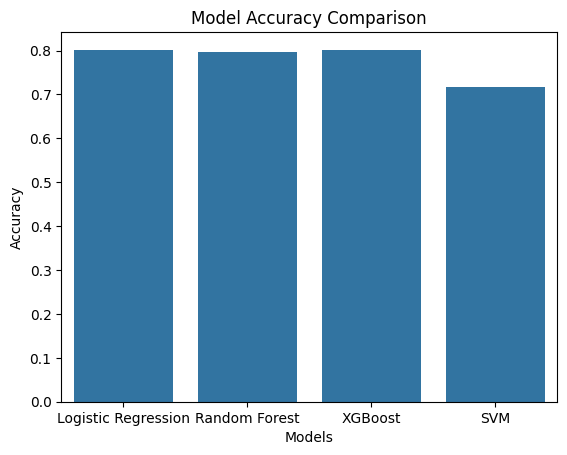

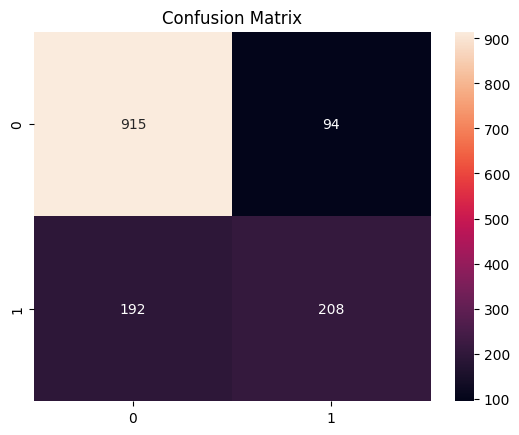

              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1009
           1       0.69      0.52      0.59       400

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



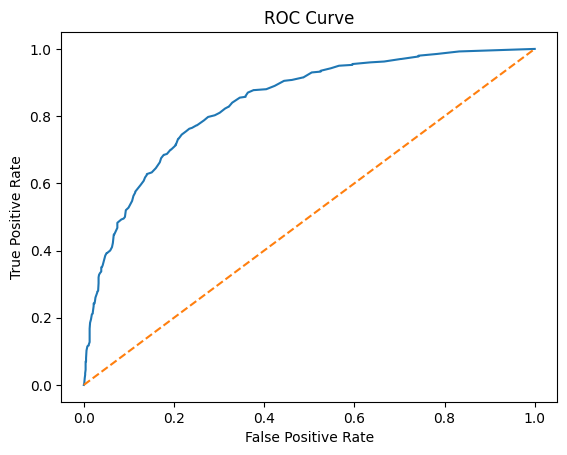

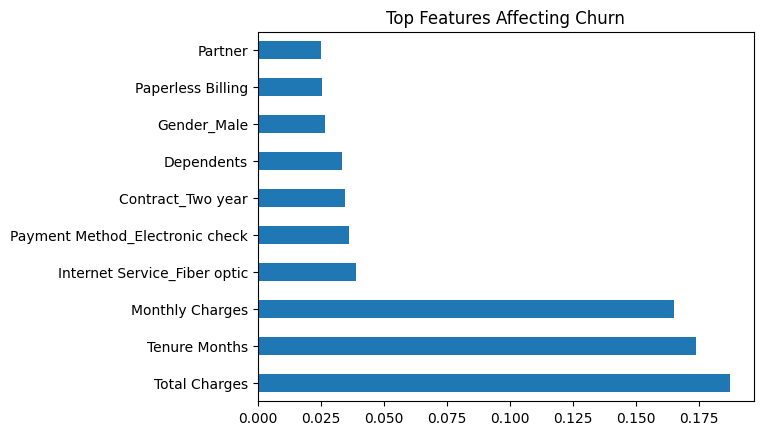

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


df = pd.read_excel(r"C:\Users\LENOVO\Desktop\Customer Churn Analysis Project\Dataset\Telco_customer_churn.xlsx")

df.drop("CustomerID", axis=1, inplace=True)

drop_cols = [
    'Count',
    'Country',
    'State',
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Reason',
    'Churn Value',
    'Churn Score',
    'CLTV'
]

df.drop(columns=drop_cols, inplace=True)

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.show()

#ENCODING 

binary_cols = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Churn Label']

for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

categorical_cols = [
    'Internet Service',
    'Contract',
    'Payment Method'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

categorical_cols = df.select_dtypes(include=['object','string']).columns

print(categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#VISUALIZATION 
sns.countplot(x='Churn Label', data=df)
plt.title("Customer Churn Distribution")
plt.show()

sns.countplot(x='Contract_Two year', hue='Churn Label', data=df)
plt.show()

sns.histplot(data=df, x='Monthly Charges', kde=True, hue='Churn Label')
plt.show()

sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.show()

sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.show()

# ML TRAINING
X = df.drop("Churn Label", axis=1)

y = df["Churn Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# RANDOM FOREST
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# XGBoost Classifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# SVM

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

# MODEL EVALUATION

#ACCURACY SCORE 
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_svm)
]

sns.barplot(x=models, y=accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()


#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#Classification Report
print(classification_report(y_test, y_pred_rf))

#ROC-AUC Score
roc_auc_score(y_test, y_pred_rf)

#ROC Curve
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#Feature importance extraction
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
) 
importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.show()
